# Project 2 - Sargent
### SQL Analysis with O-List E Commerce Data

In [1]:
import pandas as pd
import sqlite3

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [3]:
# Load data CSVs after downloading from Kaggle
# Files link: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
base_path = "/Users/catherinedouglas/downloads/archive (4)/"
orders = pd.read_csv(base_path + "olist_orders_dataset.csv")
customers = pd.read_csv(base_path + "olist_customers_dataset.csv")
order_items = pd.read_csv(base_path + "olist_order_items_dataset.csv")
payments = pd.read_csv(base_path + "olist_order_payments_dataset.csv")
reviews = pd.read_csv(base_path + "olist_order_reviews_dataset.csv")
products = pd.read_csv(base_path + "olist_products_dataset.csv")
sellers = pd.read_csv(base_path + "olist_sellers_dataset.csv")
category_translation = pd.read_csv(base_path + "product_category_name_translation.csv")

In [5]:
# Creat the DB  - found memory syntax in sqlite handbook
connection = sqlite3.connect(":memory:")

orders.to_sql("orders", connection, index=False, if_exists="replace")
customers.to_sql("customers", connection, index=False, if_exists="replace")
order_items.to_sql("order_items", connection, index=False, if_exists="replace")
payments.to_sql("payments", connection, index=False, if_exists="replace")
reviews.to_sql("reviews", connection, index=False, if_exists="replace")
products.to_sql("products", connection, index=False, if_exists="replace")
sellers.to_sql("sellers", connection, index=False, if_exists="replace")
category_translation.to_sql("category_translation", connection, index=False, if_exists="replace")

71

In [7]:
# Run query function
def run_query(sql):
    return pd.read_sql_query(sql, connection)

In [8]:
# Query for portfolio quality #1 Monthly Revenue Trends
run_query("""
SELECT
    substr(order_purchase_timestamp, 1, 7) AS month,
    ROUND(SUM(payment_value), 2) AS revenue
FROM orders o
JOIN payments p ON o.order_id = p.order_id
WHERE order_status = 'delivered'
GROUP BY month
ORDER BY month;
""")

,month,revenue
0,2016-10,46566.71
1,2016-12,19.62
2,2017-01,127545.67
3,2017-02,271298.65
4,2017-03,414369.39
5,2017-04,390952.18
6,2017-05,567066.73
7,2017-06,490225.60
8,2017-07,566403.93
9,2017-08,646000.61


In [12]:
# Query for Portfolio Quality #2 Top Product Categories
run_query("""
SELECT
    ct.product_category_name_english AS category,
    ROUND(SUM(oi.price), 2) AS revenue,
    COUNT(DISTINCT oi.order_id) AS orders
FROM order_items oi
JOIN products pr ON oi.product_id = pr.product_id
LEFT JOIN category_translation ct
    ON pr.product_category_name = ct.product_category_name
GROUP BY category
ORDER BY revenue DESC
LIMIT 10;
""")

,category,revenue,orders
0,health_beauty,1258681.34,8836
1,watches_gifts,1205005.68,5624
2,bed_bath_table,1036988.68,9417
3,sports_leisure,988048.97,7720
4,computers_accessories,911954.32,6689
5,furniture_decor,729762.49,6449
6,cool_stuff,635290.85,3632
7,housewares,632248.66,5884
8,auto,592720.11,3897
9,garden_tools,485256.46,3518


In [11]:
# Querying Portfolio Quality #3 Delivery Time by State
run_query("""
SELECT
    c.customer_state,
    COUNT(*) AS orders,
    ROUND(AVG(julianday(o.order_delivered_customer_date) - julianday(o.order_purchase_timestamp)), 1) AS avg_days
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
AND o.order_delivered_customer_date IS NOT NULL
GROUP BY c.customer_state
ORDER BY avg_days DESC;
""")

,customer_state,orders,avg_days
0,RR,41,29.4
1,AP,67,27.2
2,AM,145,26.4
3,AL,397,24.5
4,PA,946,23.8
5,MA,717,21.6
6,SE,335,21.5
7,CE,1279,21.3
8,AC,80,21.0
9,PB,517,20.4


In [13]:
# Querying Portfolio Quality #4 Delivery Speed vs Reviews
run_query("""
SELECT
    CASE
        WHEN julianday(order_delivered_customer_date) - julianday(order_purchase_timestamp) <= 7 THEN 'Fast'
        WHEN julianday(order_delivered_customer_date) - julianday(order_purchase_timestamp) <= 14 THEN 'Medium'
        ELSE 'Slow'
    END AS delivery_speed,
    COUNT(*) AS orders,
    ROUND(AVG(review_score), 2) AS avg_review
FROM orders o
JOIN reviews r ON o.order_id = r.order_id
WHERE order_status = 'delivered'
AND order_delivered_customer_date IS NOT NULL
GROUP BY delivery_speed;
""")

,delivery_speed,orders,avg_review
0,Fast,26040,4.42
1,Medium,40214,4.31
2,Slow,30099,3.72


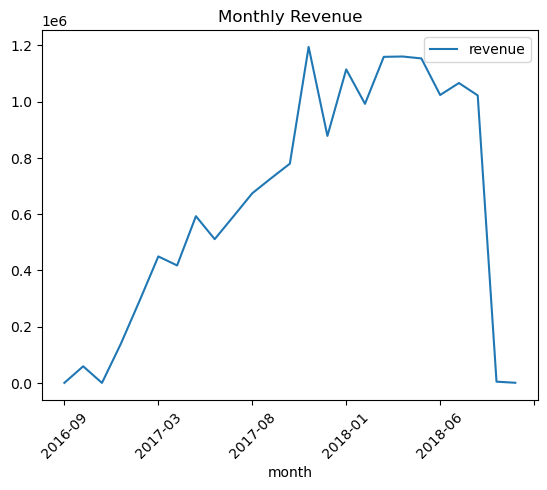

In [14]:
# Data Visualization
import matplotlib.pyplot as plt

df = run_query("""
SELECT
    substr(order_purchase_timestamp, 1, 7) AS month,
    SUM(payment_value) AS revenue
FROM orders o
JOIN payments p ON o.order_id = p.order_id
GROUP BY month
ORDER BY month;
""")

df.plot(x="month", y="revenue", kind="line", title="Monthly Revenue")
plt.xticks(rotation=45)
plt.show()